In [1]:
%cd /home/dinh/graph-based_action-recognition

/home/dinh/graph-based_action-recognition


# Requiremets

In [2]:
import csv
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from ipywidgets import Button, IntSlider, HBox, VBox
from IPython.display import display
import matplotlib.cm as cm
import numpy as np
import torch

# Data Cleaning

In [3]:
df = pd.read_csv("data/MOCAP/Annotations.tsv", sep="\t")
print(df.to_string()) 

                                                                        CSV     a X mains Torse Tete Mains Autre (Bras ou jambes) Fixe  Sym
0                                                         RST_X0062.mots1_0    à une main   Non  Non   Non                    Non  Oui  NaN
1                                                       RST_X0063.mots1_1,5    à une main   Non  Non   Non                    Non  Non  NaN
2                                                       RST_X0063.mots6_212    à une main   Non  Non   Non                    Non  Non  NaN
3                                                RST_X0064.mots12_atteindre  à deux mains   Non  Non   Oui                    Non  Non  Non
4                                                       RST_X0064.mots1_743  à deux mains   Non  Non   Non                    Non  Non  Non
5                                               RST_X0064.mots3_a propos de  à deux mains   Non  Non   Non                    Non  Non  Oui
6                   

In [4]:
print(f"Number of annotated samples: {len(df)}")
print(f"Number of samples with two hands: {df["a X mains"].value_counts()["à deux mains"]}/{len(df)}")
print(f"Number of samples with right hand closed to body: {df["Torse"].value_counts()["Oui"]}/{len(df)}")
print(f"Number of samples with right hand closed to head: {df["Tete"].value_counts()["Oui"]}/{len(df)}")
print(f"Number of samples with right hands closed together: {df["Mains"].value_counts()["Oui"]}/{len(df)}")
print(f"Number of samples with one hand fixed: {df["Fixe"].value_counts()["Oui"]}/{len(df)}")

Number of annotated samples: 5387
Number of samples with two hands: 3775/5387
Number of samples with right hand closed to body: 547/5387
Number of samples with right hand closed to head: 1485/5387
Number of samples with right hands closed together: 2522/5387
Number of samples with one hand fixed: 1598/5387


In [6]:
# Device ID = first three characters (e.g., "RST")
df["device_id"] = df["CSV"].str[:3]

# Number of unique IDs
num_ids = df["device_id"].nunique()
print("Number of unique IDs:", num_ids)

# Count occurrences per ID
id_counts = df["device_id"].value_counts()
print(id_counts)


Number of unique IDs: 7
device_id
LF2    1710
MLD    1558
LF3    1303
RST     278
LA1     278
RO1     257
LA2       3
Name: count, dtype: int64


In [22]:
skeleton_dir = "data/MOCAP"

dir_files = {f[:-4] for f in os.listdir(skeleton_dir)}  # strip extensions
annotated = set(annotated_file_names)

# Keep only valid files
valid_files = list(dir_files & annotated)

print("Number of valid annotated skeleton files:", len(valid_files))
print("Valid files:", valid_files)

Number of valid annotated skeleton files: 5353
Valid files: ['LF2_X0083_01222-07725-07918-INTERIM', 'MLD_X0061_01393-22467-22721-chef', 'LF2_X0054_00669-04797-04966-CUISSE', 'MLD_X0010_00139-02664-02964-arranger', 'MLD_X0064_01476-22382-22678-pays', 'LF2_X0089_01355-14238-14409-LOUP', 'MLD_X0059_01316-00393-00602-parce_que_', 'LF3_X0030_00416-02895-03084-DANGER', 'LF2_X0009_00027-13081-13320-ADDITION', 'LF2_X0028_00295-02628-02835-BOUCLES_D_OREILLES', 'LF2_X0093_01401-00544-00911-MANIAQUE', 'LF2_X0080_01163-11453-11637-HOMOSEXUEL', 'LF2_X0082_01201-08673-08891-INDOLORE', 'MLD_X0041_00848-00303-00582-Turquie', 'MLD_X0064_01462-09100-09315-monsieur', 'LF3_X0022_00231-12082-12332-POUSSETTE', 'MLD_X0051_01160-17121-17327-vocabulaire', 'RO1_X0040.Mots8_noircouleur', 'LF2_X0016_00110-04840-05089-ANXIEUX', 'MLD_X0011_00163-04652-04901-Autriche', 'LA1_X0020_00234-05278-05534-BUSHES', 'LF3_X0084_00271-06848-07076-TRES_IMPORTANT', 'LF2_X0008_00002-01755-01952-ABCES', 'LF2_X0063_00845-04462-04665

# READ FILE

In [10]:
def read_mocap_skeleton(skeleton_file_path):
    frames = []
    with open(skeleton_file_path, newline='') as file:
        csv_reader = csv.reader(file, delimiter='\t')
        joint_names_row = next(csv_reader)
        header_row = next(csv_reader)
        for row in csv_reader:
            # print(row[0].split(";"))
            row = row[0].split(";")
            joints = []
            for j in range(2, len(row[2:]), 3):
                coordinate = []
                for c in range(j, j+3):
                    coordinate.append(float(row[c]))
                joints.append(coordinate)
            frames.append(joints)

    return frames
            # frames.append(row[0].split(";"))

In [11]:
skeleton_lengths = []

for file_name in valid_files:
    full_file_name = "data/MOCAP/" + file_name + ".csv"
    skeleton_sequence = read_mocap_skeleton(full_file_name)
    skeleton_lengths.append(len(skeleton_sequence))

NameError: name 'valid_files' is not defined

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose skeleton_lengths is a 1D array or list
skeleton_lengths = np.array(skeleton_lengths)

# Print basic statistics
print("Mean:", np.mean(skeleton_lengths))
print("Median:", np.median(skeleton_lengths))
print("Max:", np.max(skeleton_lengths))
print("Min:", np.min(skeleton_lengths))

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(skeleton_lengths, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Skeleton Length")
plt.ylabel("Frequency")
plt.title("Histogram of Skeleton Lengths")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Mean: nan
Median: nan


/home/dinh/miniconda3/envs/graph-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dinh/miniconda3/envs/graph-env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation maximum which has no identity

# VISUALIZATION

In [7]:
CONNECTING_JOINT = [1, 2, 1, 0, 0, 11, 11, 14, 14, 3, 9, 10, 4, 12, 13]
DIRECTED_EDGES = [(i, CONNECTING_JOINT[i]) for i in range(len(CONNECTING_JOINT))]
BIDIRECTED_EDGES = DIRECTED_EDGES + [(v, u) for u, v in DIRECTED_EDGES]
EDGE_INDEX = torch.tensor(BIDIRECTED_EDGES, dtype=torch.long).t()

print(DIRECTED_EDGES)
print(BIDIRECTED_EDGES)
print(EDGE_INDEX)

[(0, 1), (1, 2), (2, 1), (3, 0), (4, 0), (5, 11), (6, 11), (7, 14), (8, 14), (9, 3), (10, 9), (11, 10), (12, 4), (13, 12), (14, 13)]
[(0, 1), (1, 2), (2, 1), (3, 0), (4, 0), (5, 11), (6, 11), (7, 14), (8, 14), (9, 3), (10, 9), (11, 10), (12, 4), (13, 12), (14, 13), (1, 0), (2, 1), (1, 2), (0, 3), (0, 4), (11, 5), (11, 6), (14, 7), (14, 8), (3, 9), (9, 10), (10, 11), (4, 12), (12, 13), (13, 14)]
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  1,  2,  1,
          0,  0, 11, 11, 14, 14,  3,  9, 10,  4, 12, 13],
        [ 1,  2,  1,  0,  0, 11, 11, 14, 14,  3,  9, 10,  4, 12, 13,  0,  1,  2,
          3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]])


In [8]:
%matplotlib widget

CONNECTING_JOINT = [1, 2, 1, 0, 0, 11, 11, 14, 14, 3, 9, 10, 4, 12, 13]


def draw_frame_3d(ax, joints, zoom_factor=1.0):
    ax.clear()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    drawn = True

    # Assign distinct colors to bodies        
    color = plt.get_cmap('Blues')(0.5)   # Cycle if more than 10 bodies

    xs = np.array([joint[0] for joint in joints])
    ys = np.array([joint[1] for joint in joints])       # Z as vertical
    zs = np.array([joint[2] for joint in joints])      # Flip Y-axis
    
    # Center skeleton at spine base (joint 0)
    # center = np.array([xs[0], ys[0], zs[0]])
    # xs -= center[0]
    # ys -= center[1]
    # zs -= center[2]

    ax.scatter(xs, ys, zs, c=[color], s=20)
    for j in range(15):
        k = CONNECTING_JOINT[j]
        if 0 <= k < 15:
            ax.plot([xs[j], xs[k]], [ys[j], ys[k]], [zs[j], zs[k]], color=color, linewidth=2)

    ax.set_xlim(min(xs)-10, max(xs)+10)
    ax.set_ylim(min(ys)-10, max(ys)+10)
    ax.set_zlim(min(zs)-10, max(zs)+10)

    if not drawn:
        ax.set_title("No valid joint data to draw")

def display_widget_3d(filename, pre_processing=False):
    skeleton_data = read_mocap_skeleton(filename)
    # if pre_processing:
        # skeleton_data = pre_process(skeleton_data)
    total_frames = len(skeleton_data)

    state = {
        "current_frame": 1,
        "zoom_factor": 1.0,
        "is_playing": True,
        "slider_is_moving": False
    }

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    def update(frame):
        state["current_frame"] = frame
        draw_frame_3d(ax, skeleton_data[frame - 1], state["zoom_factor"])
        ax.set_title(f"Frame: {frame} / {total_frames}")
        if not state["slider_is_moving"]:
            frame_slider.value = frame

    anim = FuncAnimation(fig, update, frames=range(1, total_frames + 1), interval=100)
    anim.event_source.stop()

    # Button callbacks
    def on_play_pause_clicked(b):
        if state["is_playing"]:
            anim.event_source.stop()
            b.description = "Play"
        else:
            anim.event_source.start()
            b.description = "Pause"
        state["is_playing"] = not state["is_playing"]

    def on_step_clicked(b):
        if state["current_frame"] < total_frames:
            state["current_frame"] += 1
            anim.event_source.stop()
            play_pause_btn.description = "Play"
            update(state["current_frame"])
            state["is_playing"] = False

    def on_replay_clicked(b):
        state["current_frame"] = 1
        state["zoom_factor"] = 1.0
        state["is_playing"] = True
        anim.event_source.stop()
        play_pause_btn.description = "Play"
        update(1)

    def on_zoom_in_clicked(b):
        state["zoom_factor"] *= 1.25
        update(state["current_frame"])

    def on_zoom_out_clicked(b):
        state["zoom_factor"] /= 1.25
        update(state["current_frame"])

    def on_save_gif_clicked(b):
        gif_name = os.path.splitext(os.path.basename(filename))[0] + "_3d.gif"
        print(f"Saving animation to {gif_name}...")
        temp_anim = FuncAnimation(fig, update, frames=range(1, total_frames + 1), interval=100, repeat=False)
        temp_anim.save(gif_name, writer=PillowWriter(fps=10))
        print("GIF saved successfully.")

    def on_close_clicked(b):
        anim.event_source.stop()
        plt.close(fig)

    def on_frame_slider_change(change):
        if change['name'] == 'value':
            state["slider_is_moving"] = True
            new_frame = change['new']
            if new_frame != state["current_frame"]:
                state["current_frame"] = new_frame
                anim.event_source.stop()
                play_pause_btn.description = "Play"
                state["is_playing"] = False
                update(new_frame)
            state["slider_is_moving"] = False

    # Widgets
    play_pause_btn = Button(description="Pause")
    play_pause_btn.on_click(on_play_pause_clicked)

    step_btn = Button(description="Step")
    step_btn.on_click(on_step_clicked)

    replay_btn = Button(description="Replay")
    replay_btn.on_click(on_replay_clicked)

    zoom_in_btn = Button(description="Zoom In")
    zoom_in_btn.on_click(on_zoom_in_clicked)

    zoom_out_btn = Button(description="Zoom Out")
    zoom_out_btn.on_click(on_zoom_out_clicked)

    save_gif_btn = Button(description="Save GIF")
    save_gif_btn.on_click(on_save_gif_clicked)

    close_btn = Button(description="Close")
    close_btn.on_click(on_close_clicked)

    frame_slider = IntSlider(value=1, min=1, max=total_frames, description='Frame')
    frame_slider.observe(on_frame_slider_change, names='value')

    controls = HBox([
        play_pause_btn, step_btn, replay_btn,
        zoom_in_btn, zoom_out_btn, save_gif_btn,
        close_btn
    ])

    ui = VBox([controls, frame_slider])
    display(ui)

def draw_skeleton_3d(filename: str, pre_processing=False, save=False):
    skeleton_data = read_mocap_skeleton(filename)
    # if pre_processing:
        # skeleton_data = pre_process(skeleton_data)

    if save:
        print("Saving directly to GIF...")
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')

        def update(frame):
            draw_frame_3d(ax, skeleton_data[frame - 1], zoom_factor=1.0)
            ax.set_title(f"Frame: {frame} / {len(skeleton_data)}")

        anim = FuncAnimation(fig, update, frames=range(1, len(skeleton_data) + 1), interval=100, repeat=False)
        gif_name = os.path.splitext(os.path.basename(filename))[0] + "_3d.gif"
        anim.save(gif_name, writer=PillowWriter(fps=10))
        print(f"GIF saved to: {gif_name}")
    else:
        display_widget_3d(filename, pre_processing)


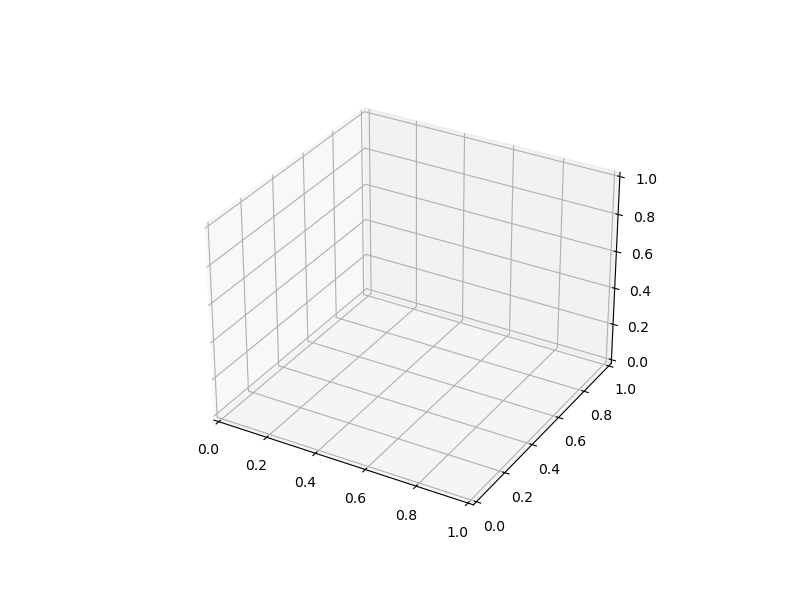

In [13]:
draw_skeleton_3d("data/MOCAP/MLD_X0043_00925-07480-07730-avantage.csv", pre_processing=True, save=False)

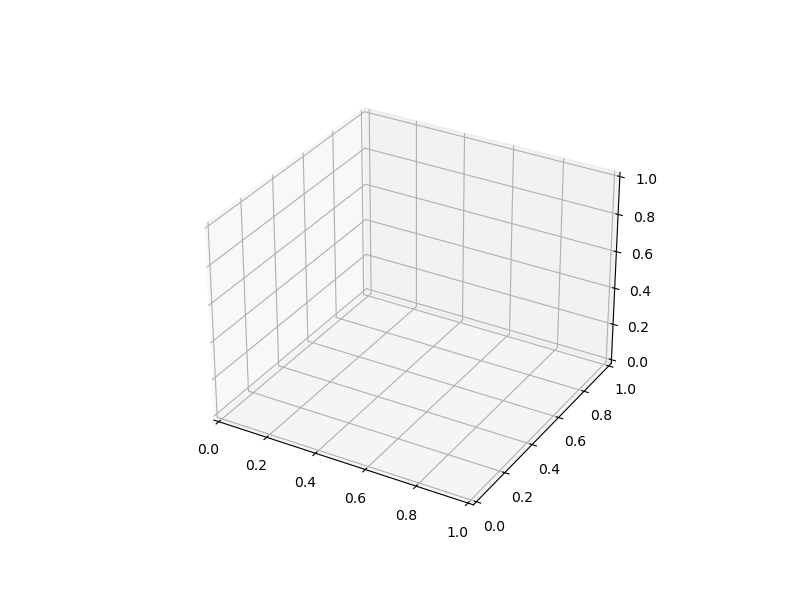

In [14]:
draw_skeleton_3d("data/MOCAP/LF2_X0016_00113-07760-07960-APPELER.csv", pre_processing=True, save=False)

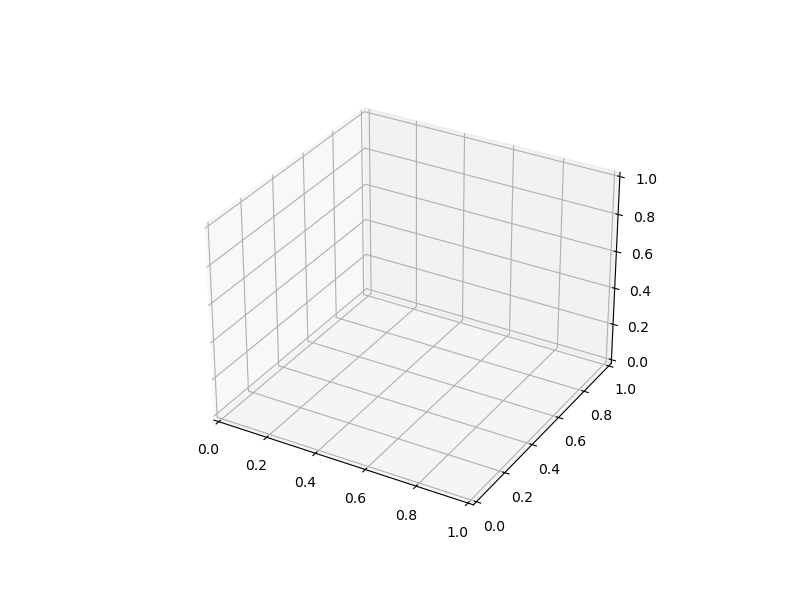

In [15]:
draw_skeleton_3d("data/MOCAP/LF3_X0021_00182-02104-02305-ODORAT.csv", pre_processing=True, save=False)